<a href="https://colab.research.google.com/github/linoy25/Project-OnlyPlants/blob/main/Tutorials/tirgul1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
print(time.ctime())

Fri May 15 19:21:56 2026


In [ ]:
print("Hello, world!")

Hello, world!


In [ ]:
!pip install numpy

In [ ]:
!ls "/content/drive/My Drive/Colab Notebooks"

 cloud	'Copy of lab4_ex1.ipynb'   DataMiningLab   Untitled0.ipynb


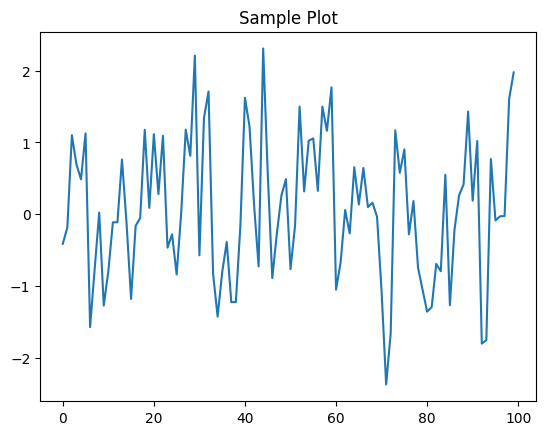

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

y = np.random.randn(100)
x = [x for x in range(len(y))]

plt.plot(x, y, '-')
plt.fill_between(x, y, 200, where = (y > 195), facecolor='g', alpha=0.6)

plt.title("Sample Plot")
plt.show()


In [ ]:
# @title Default title text


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/cloud/students.txt'

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Function to read data from the file
def load_students():
    students_data = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split(',')
                # Ensures there is enough data in the row
                if len(parts) >= 5:
                    full_name = f"{parts[0]} {parts[1]}"
                    # Saves the full line and data in a dictionary
                    students_data[full_name] = {
                        'first': parts[0],
                        'last': parts[1],
                        'email': parts[2],
                        'courses': parts[3],
                        'link': parts[4],
                        'raw_line': line.strip()
                    }
    return students_data

students_data = load_students()
student_names = ['Select Student...'] + list(students_data.keys())

# --- Widget Creation (Text boxes and buttons) ---

dropdown_students = widgets.Dropdown(options=student_names, description='Student:')

# Text boxes for displaying data (set to disabled so they are read-only)
txt_first = widgets.Text(description='First Name:', disabled=True)
txt_last = widgets.Text(description='Last Name:', disabled=True)
txt_email = widgets.Text(description='Email:', disabled=True)
txt_courses = widgets.Text(description='Courses:', disabled=True)
txt_link = widgets.Text(description='Link:', disabled=True)

# Text box for updating favorite TV show
txt_tv_show = widgets.Text(description='TV Show:', placeholder='Enter TV show...')

btn_update = widgets.Button(description='Update File', button_style='success', icon='check')
output = widgets.Output()

# --- Event Functions ---

# What happens when a different student is selected from the list?
def on_student_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        selected = change['new']
        if selected in students_data:
            data = students_data[selected]
            txt_first.value = data['first']
            txt_last.value = data['last']
            txt_email.value = data['email']
            txt_courses.value = data['courses']
            txt_link.value = data['link']
            txt_tv_show.value = '' # Reset the TV show box for a new selection
        else:
            # Reset boxes if no specific student is selected
            for txt in [txt_first, txt_last, txt_email, txt_courses, txt_link, txt_tv_show]:
                txt.value = ''

dropdown_students.observe(on_student_change)

# What happens when the update button is clicked?
def on_update_click(b):
    with output:
        output.clear_output()
        selected = dropdown_students.value
        tv_show = txt_tv_show.value

        if selected == 'Select Student...':
            print("Please select a student from the list.")
            return
        if not tv_show:
            print("Please enter a TV show.")
            return

        data = students_data[selected]
        # Creating the new line that includes all the old info + the favorite TV show
        new_line = f"{data['raw_line']},{tv_show}\n"

        # 'a' (append) opens the file in append mode so it doesn't delete what already exists
        with open(file_path, 'a', encoding='utf-8') as f:
            f.write(new_line)

        print(f"The new line was successfully added to the file for {selected}!")

btn_update.on_click(on_update_click)

# --- Form Layout and Design ---
form_layout = widgets.VBox([
    widgets.HTML("<h2>Student Update Form</h2>"),
    dropdown_students,
    widgets.HTML("<hr>"),
    widgets.HBox([txt_first, txt_last]),
    widgets.HBox([txt_email, txt_courses]),
    txt_link,
    widgets.HTML("<hr><b>Update Details:</b>"),
    widgets.HBox([txt_tv_show, btn_update]),
    output
])

# Display the form
display(form_layout)